# 10 · Texture: does spatial pattern help separate forest from pasture?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bullocke/nice-sar/blob/main/notebooks/10_texture_comparison.ipynb)

Backscatter brightness is not the only clue in a radar image. Forest canopies, pasture and regrowth also differ in how brightness varies from pixel to pixel, which image analysts call **texture**. This notebook computes two families of texture measures on NISAR HV over Caquetá, Colombia, and tests which ones separate forest from pasture.

**What you will learn**

- Fast first-order texture with rank filters (`compute_rank_texture`) and local statistics (`compute_local_contrast_homogeneity`).
- Second-order (co-occurrence) Haralick texture with `compute_glcm_texture`.
- How to rank features by how well they separate two land-cover classes.

> **Provisional data.** NISAR products used here are PROVISIONAL: calibrated but only partly validated. Numbers may shift once validated products are released.

**Runtime:** about 1 minute with the demo bundle (no login needed). GLCM texture is much faster with `numba` installed (`pip install "nice-sar[accel]"`); without it this notebook takes a few minutes.

In [1]:
# Colab only: install nice-sar (about 1 minute)
import sys

if "google.colab" in sys.modules:
    %pip install -q "fsspec<=2025.3.0" "s3fs<=2025.3.0" "nice-sar @ git+https://github.com/bullocke/nice-sar.git@main"

In [2]:
import logging
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu

from nice_sar.datasets import load_caqueta_demo
from nice_sar.preprocess.texture import (
    HARALICK_FEATURES,
    compute_glcm_texture,
    compute_local_contrast_homogeneity,
    compute_rank_texture,
)
from nice_sar.viz.style import CMAPS, COLORS, add_colorbar, add_scalebar, image_axes, use_nice_style

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s", force=True)
logging.getLogger("PIL").setLevel(logging.WARNING)
log = logging.getLogger("nb10")
warnings.filterwarnings("ignore", message="(All-NaN slice|Mean of empty slice|Degrees of freedom)")
use_nice_style()
%config InlineBackend.figure_formats = ["jpeg"]
%config InlineBackend.print_figure_kwargs = {"bbox_inches": "tight", "pil_kwargs": {"quality": 90}}

## 1. A 6 × 6 km test area

We work on a 300 × 300 pixel (6 × 6 km) window of the Caquetá demo bundle that mixes intact forest, long-standing pasture and a river. Texture should describe the land surface, not radar speckle, so we average all 11 HV dates (December 2025 to August 2026) in linear power first. To use your own data, stream a window with `read_gcov(url, polarization="HV", bbox=..., filesystem=fs)` as in [02 · Read GCOV](02_read_gcov.ipynb).

Reference classes come from the bundle's RADD layers: **forest** is RADD primary forest never alerted and at least 100 m from any alert; **pasture** is land RADD flagged as cleared at least 90 days before the series began.

INFO: Caquetá demo: 11 HV dates, 21 coherence pairs, 40 cases


INFO: Window: 50719 forest px, 13424 pasture px


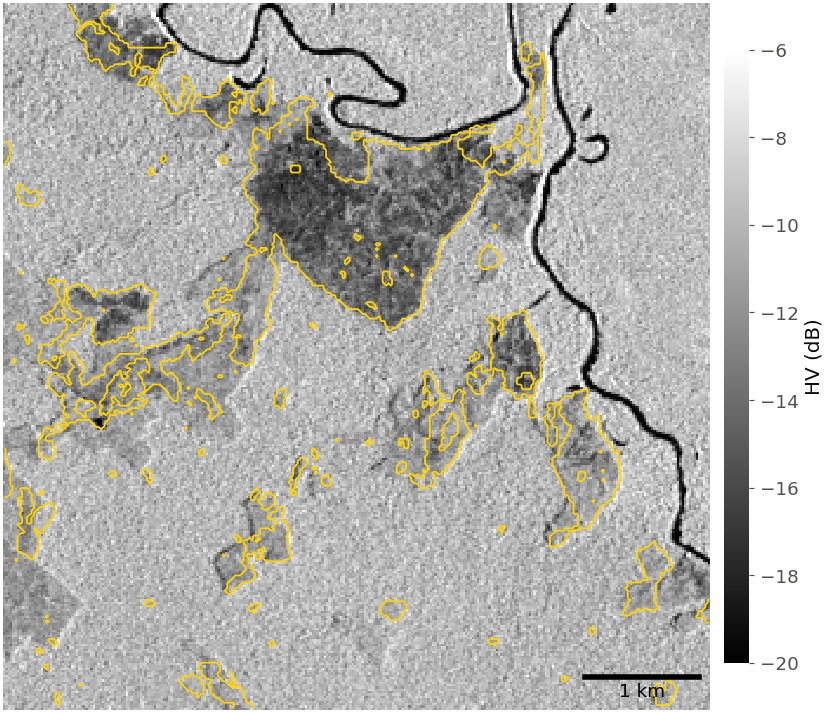

In [3]:
demo = load_caqueta_demo()
PX = demo.pixel_m
win = (slice(50, 350), slice(780, 1080))
hv_db = (10 * np.log10(np.nanmean(10 ** (demo.hv / 10), 0)))[win]
forest = demo.stable_forest()[win]
pasture = ((demo.radd_conf > 0) & (demo.radd_alert < demo.hv_dates[0] - np.timedelta64(90, "D")))[win]
log.info("Window: %d forest px, %d pasture px", forest.sum(), pasture.sum())

fig, ax = plt.subplots(figsize=(7.5, 6.6))
im = ax.imshow(hv_db, **CMAPS["hv"])
ax.contour(pasture.astype(float), levels=[0.5], colors=COLORS["outline"], linewidths=1.2)
image_axes(ax)
add_scalebar(ax, PX, color="black")
add_colorbar(im, ax, "HV (dB)")
plt.show()

Yellow outlines mark the reference pasture. Forest is uniformly bright; pasture is darker and patchier.

## 2. First-order texture: rank filters and local statistics

First-order measures describe the distribution of values in a moving window, ignoring how they are arranged. `compute_rank_texture` quantizes the image into 32 grey levels and returns the local **mean**, **entropy** (how evenly the grey levels are spread across the window) and **range**. `compute_local_contrast_homogeneity` returns the local standard deviation (**contrast**) and 1 / (1 + coefficient of variation) (**homogeneity**). The coefficient of variation only makes sense for positive values, so we pass HV in linear power rather than dB. We use an 11-pixel (220 m) window.

INFO: Computing texture features (window=11)


INFO: First-order texture in 3.4 s


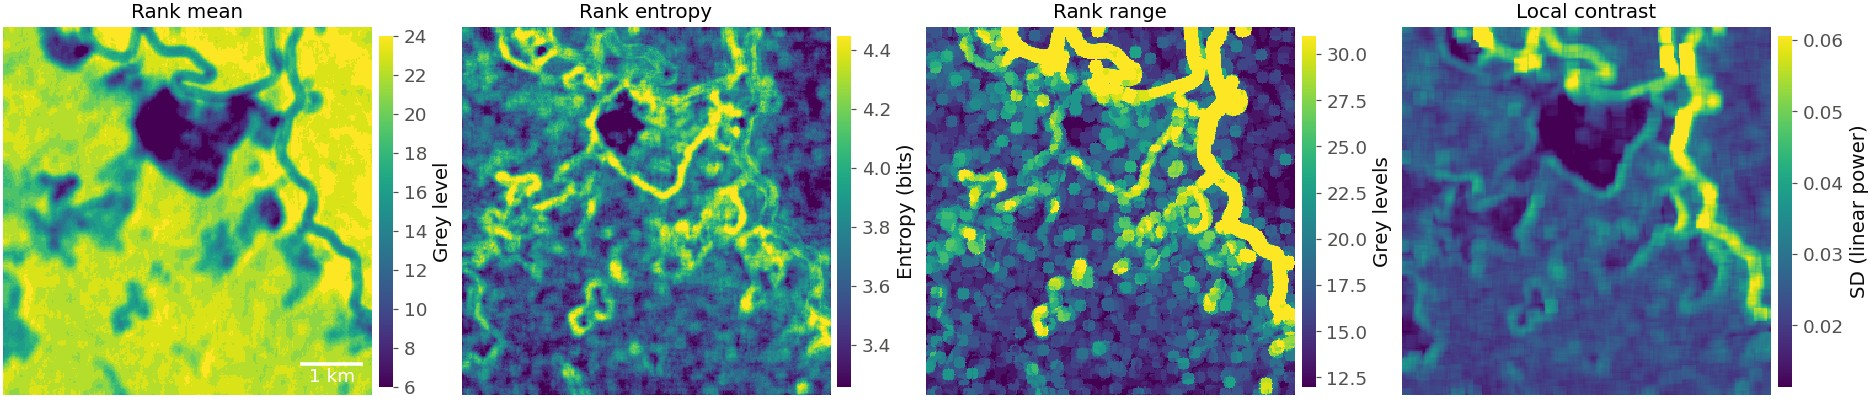

In [4]:
t0 = time.perf_counter()
rank = compute_rank_texture(hv_db, window_size=11, levels=32)
contrast, homogeneity = compute_local_contrast_homogeneity(10 ** (hv_db / 10), window_size=11)
log.info("First-order texture in %.1f s", time.perf_counter() - t0)

first_order = {
    "Rank mean": rank["mean"],
    "Rank entropy": rank["entropy"],
    "Rank range": rank["range"],
    "Local contrast": contrast,
}
units = {"Rank mean": "Grey level", "Rank entropy": "Entropy (bits)", "Rank range": "Grey levels", "Local contrast": "SD (linear power)"}
fig, axes = plt.subplots(1, 4, figsize=(17, 4.6))
for ax, (name, img) in zip(axes, first_order.items()):
    lo, hi = np.nanpercentile(img, [2, 98])
    im = ax.imshow(img, cmap=CMAPS["index"]["cmap"], vmin=lo, vmax=hi)
    image_axes(ax, name)
    add_colorbar(im, ax, units[name], shrink=0.7)
add_scalebar(axes[0], PX)
plt.show()

## 3. Second-order texture: GLCM Haralick features

A grey-level co-occurrence matrix (GLCM) counts how often pairs of grey levels occur next to each other, here one pixel apart in four directions. Haralick's 13 features summarize that matrix: **contrast** is high where neighbours differ, **homogeneity** is high where they are alike, **correlation** measures how predictable a pixel is from its neighbour, and **entropy** measures how evenly the co-occurrence counts are spread. `compute_glcm_texture` computes any subset of them in a sliding window (7 × 7 pixels here).

INFO: Computing GLCM texture (numba, window=7, levels=32)


INFO: GLCM (6 features) in 3.8 s; all features available: asm, contrast, correlation, variance, homogeneity, sum_average, sum_variance, sum_entropy, entropy, difference_variance, difference_entropy, imc1, imc2


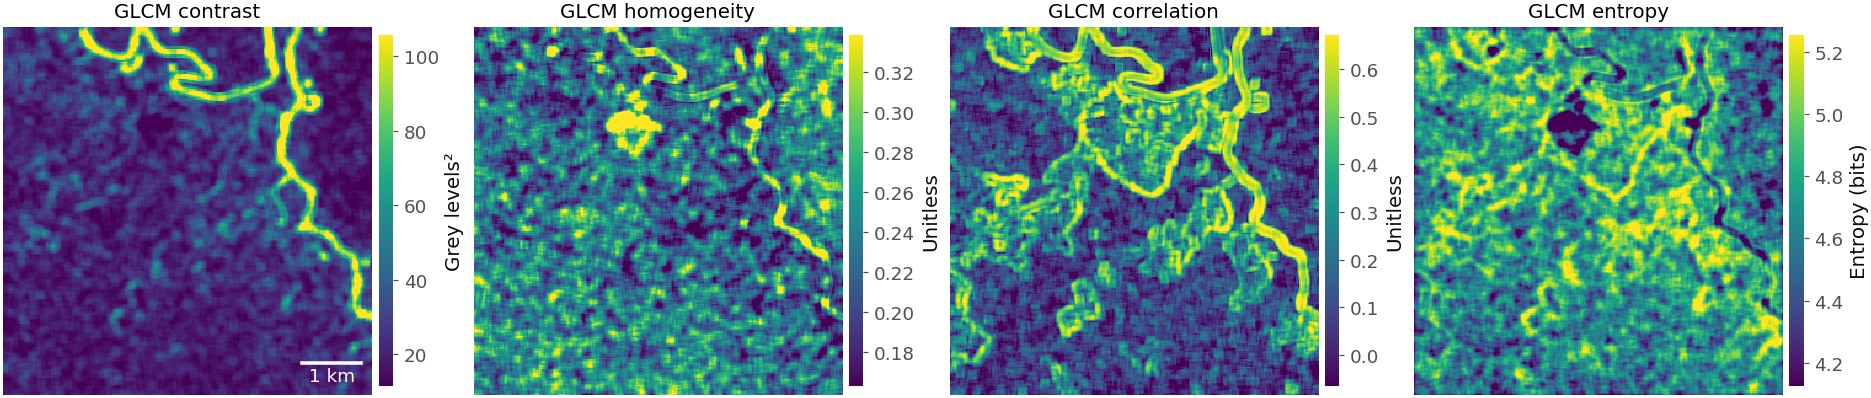

In [5]:
glcm_names = ["contrast", "homogeneity", "correlation", "entropy", "asm", "variance"]
t0 = time.perf_counter()
glcm = compute_glcm_texture(hv_db, window_size=7, levels=32, features=glcm_names)
log.info("GLCM (%d features) in %.1f s; all features available: %s", len(glcm), time.perf_counter() - t0, ", ".join(HARALICK_FEATURES))

fig, axes = plt.subplots(1, 4, figsize=(17, 4.6))
glcm_units = {"contrast": "Grey levels²", "homogeneity": "Unitless", "correlation": "Unitless", "entropy": "Entropy (bits)"}
for ax, name in zip(axes, glcm_units):
    img = glcm[name]
    lo, hi = np.nanpercentile(img, [2, 98])
    im = ax.imshow(img, cmap=CMAPS["index"]["cmap"], vmin=lo, vmax=hi)
    image_axes(ax, f"GLCM {name}")
    add_colorbar(im, ax, glcm_units[name], shrink=0.7)
add_scalebar(axes[0], PX)
plt.show()

## 4. Which features separate forest from pasture?

For each feature we compute the area under the ROC curve (AUC) between forest and pasture pixels: the probability that a randomly chosen forest pixel and a randomly chosen pasture pixel are ranked in the right order. We report separability as |AUC − 0.5| × 2, from 0 (no separation) to 1 (perfect). Plain HV brightness (orange) is the baseline to beat. Note that the rank-filter mean is not really texture: it is HV brightness averaged over the window, so it is also coloured orange.

INFO: GLCM correlation median: forest 0.08, pasture 0.38


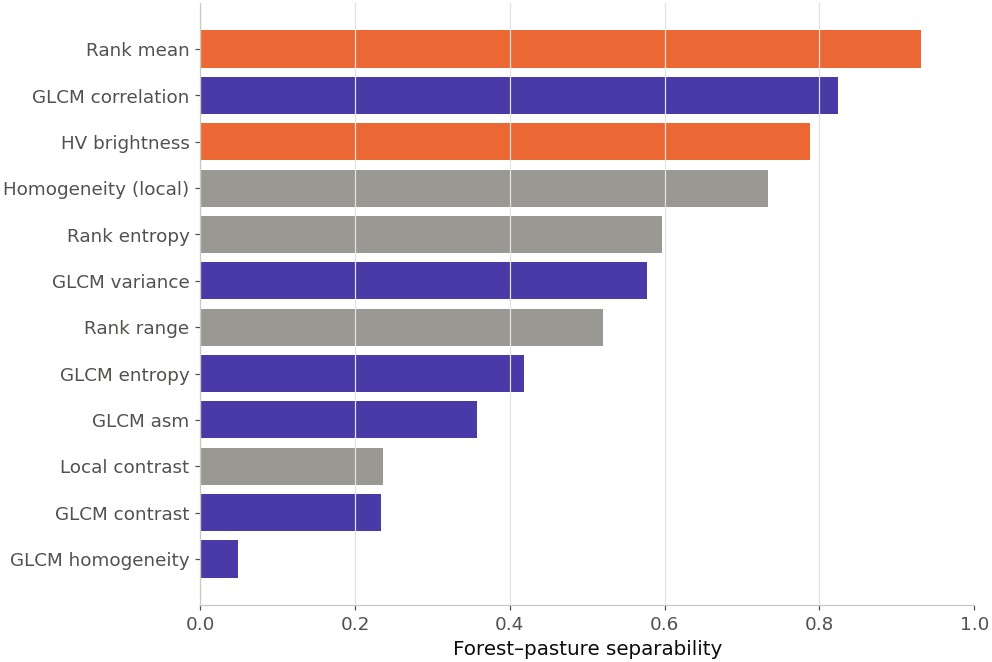

INFO: Rank mean              0.93


INFO: GLCM correlation       0.82


INFO: HV brightness          0.79


INFO: Homogeneity (local)    0.73


INFO: Rank entropy           0.60


...

INFO: GLCM entropy           0.42


INFO: GLCM asm               0.36


INFO: Local contrast         0.24


INFO: GLCM contrast          0.23


INFO: GLCM homogeneity       0.05


In [6]:
features = {"HV brightness": hv_db, "Homogeneity (local)": homogeneity, **first_order}
features |= {f"GLCM {n}": glcm[n] for n in glcm_names}


def separability(img: np.ndarray) -> float:
    a, b = img[forest], img[pasture]
    a, b = a[np.isfinite(a)], b[np.isfinite(b)]
    auc = mannwhitneyu(a, b).statistic / (a.size * b.size)
    return abs(auc - 0.5) * 2


for name in ("GLCM correlation",):
    log.info("%s median: forest %.2f, pasture %.2f", name, np.nanmedian(features[name][forest]), np.nanmedian(features[name][pasture]))
scores = dict(sorted(((k, separability(v)) for k, v in features.items()), key=lambda kv: kv[1]))
fig, ax = plt.subplots(figsize=(9, 6))
colors = [COLORS["HV"] if k in ("HV brightness", "Rank mean") else COLORS["coh20"] if k.startswith("GLCM") else COLORS["pasture"] for k in scores]
ax.barh(list(scores), list(scores.values()), color=colors)
ax.set_xlim(0, 1)
ax.set_xlabel("Forest–pasture separability")
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
plt.show()
for k, v in reversed(scores.items()):
    log.info("%-22s %.2f", k, v)

## 5. The strongest texture features side by side

The top score goes to the rank mean, which is simply HV brightness averaged over 220 m: removing the remaining speckle helps more than any texture measure. Among true texture measures, GLCM correlation stands out and beats single-pixel brightness. Forest HV varies almost randomly from one pixel to the next (low GLCM correlation, see the medians logged below), while pasture has spatial structure from fields, trees and soil moisture. Contrast-type measures mostly light up edges and the river rather than the interiors of each class. The panel shows brightness, smoothed brightness and the two best texture measures.

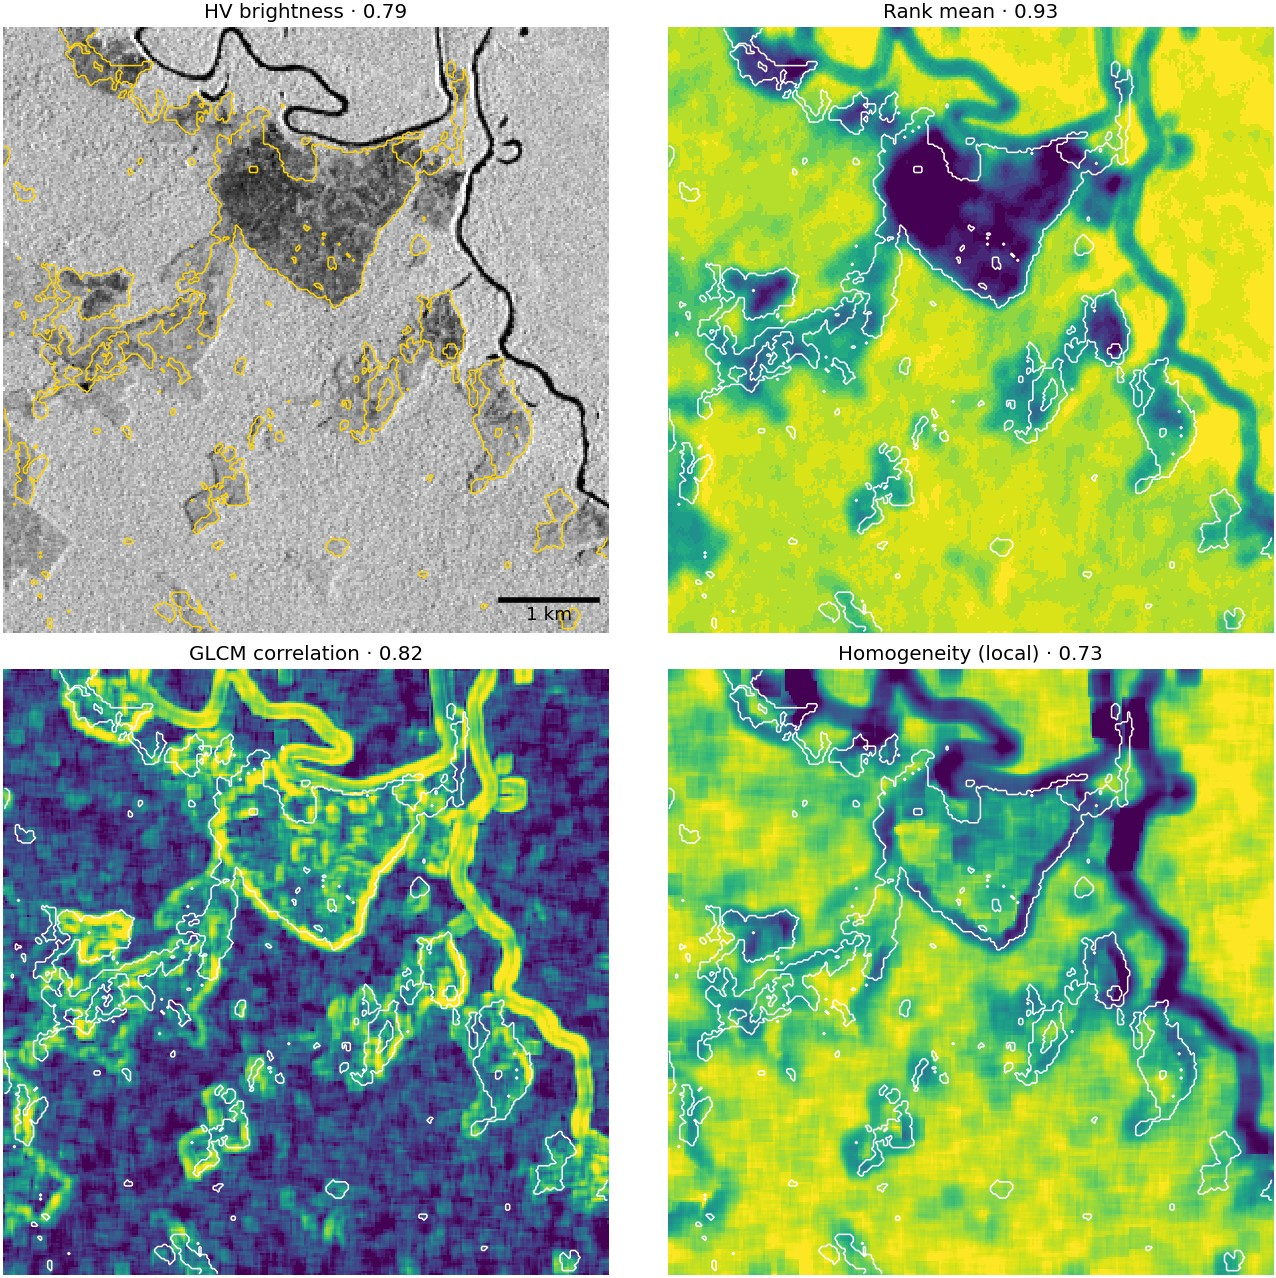

In [7]:
best = ["Rank mean"] + [k for k in reversed(scores) if k not in ("HV brightness", "Rank mean")][:2]
panels = {"HV brightness": (hv_db, CMAPS["hv"])}
for k in best:
    lo, hi = np.nanpercentile(features[k], [2, 98])
    panels[k] = (features[k], {"cmap": CMAPS["index"]["cmap"], "vmin": lo, "vmax": hi})

fig, axes = plt.subplots(2, 2, figsize=(12, 11.6))
for ax, (name, (img, kw)) in zip(axes.flat, panels.items()):
    ax.imshow(img, **kw)
    edge = COLORS["outline"] if name == "HV brightness" else "white"
    ax.contour(pasture.astype(float), levels=[0.5], colors=edge, linewidths=1.0)
    image_axes(ax, f"{name} · {scores[name]:.2f}")
add_scalebar(axes[0, 0], PX, color="black")
plt.show()

Panel titles give each feature's forest–pasture separability.

## Summary

- Rank-filter texture is fast and captures the local distribution of values; GLCM texture captures how values are arranged, at a higher computational cost.
- Smoothed brightness separates forest from pasture best in this scene. GLCM correlation is the strongest true texture measure and captures a real difference: forest HV is spatially random, pasture HV is structured.
- Contrast-type features respond mainly to edges, so they suit boundary mapping more than class interiors.
- Average several dates before computing texture, so the features describe the land surface rather than speckle.

For the full comparison of the two approaches, see [Texture measures compared](https://bullocke.github.io/nice-sar/texture-comparison/). Previous tutorial: [09 · Forest masks](09_forest_masks.ipynb). Next: [11 · Forest disturbance](11_disturbance_detection.ipynb).

In [8]:
import nice_sar

log.info("nice-sar %s, run on %s", nice_sar.__version__, np.datetime64("today"))

INFO: nice-sar 0.2.0, run on 2026-09-25
